# Quadratic Cost Demo

The attention score matrix `QK^T` has shape `(n, n)` for sequence length `n`. Its memory footprint and compute scale as `O(n^2)`. This notebook visualizes the wall — and motivates the architectural and systems-level fixes in Parts 5 and 7.

**No exercises here.** Run top to bottom.

## Setup

In [1]:
import matplotlib.pyplot as plt

## 1. Memory footprint of `QK^T` vs sequence length

For each sequence length, compute the size of the attention score matrix in MB (assuming fp16 — 2 bytes per entry).

   seq_len      QK^T (MB)
----------------------------
       512           0.50
      1024           2.00
      2048           8.00
      4096          32.00
      8192         128.00
     16384         512.00
     32768        2048.00
     65536        8192.00
    131072       32768.00


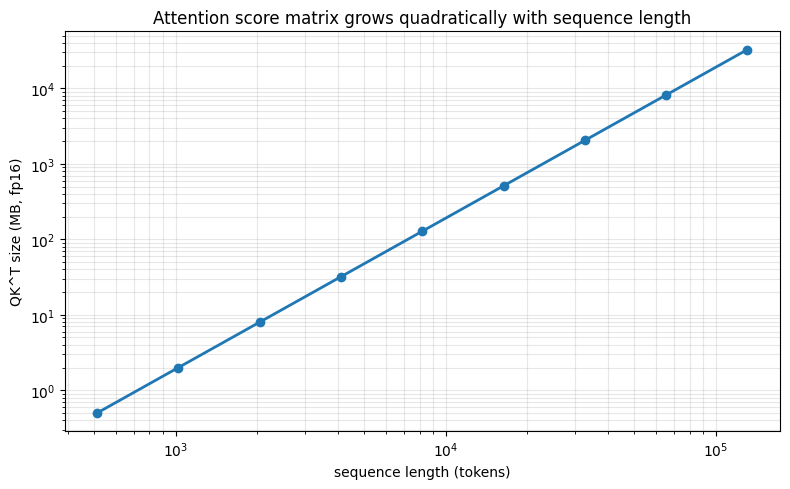

In [2]:
lengths = [512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072]
mb = [(n * n * 2) / (1024 * 1024) for n in lengths]   # fp16 = 2 bytes

print(f"{'seq_len':>10} {'QK^T (MB)':>14}")
print('-' * 28)
for n, m in zip(lengths, mb):
    print(f'{n:>10} {m:>14.2f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(lengths, mb, 'o-', linewidth=2)
ax.set_xlabel('sequence length (tokens)')
ax.set_ylabel('QK^T size (MB, fp16)')
ax.set_title('Attention score matrix grows quadratically with sequence length')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Per-layer, per-head scaling

For a real model — say 32 layers, 32 heads, fp16 — what's the total attention memory at each context length?

   seq_len     total (GB)
----------------------------
       512           0.50
      1024           2.00
      2048           8.00
      4096          32.00
      8192         128.00
     16384         512.00
     32768        2048.00
     65536        8192.00
    131072       32768.00


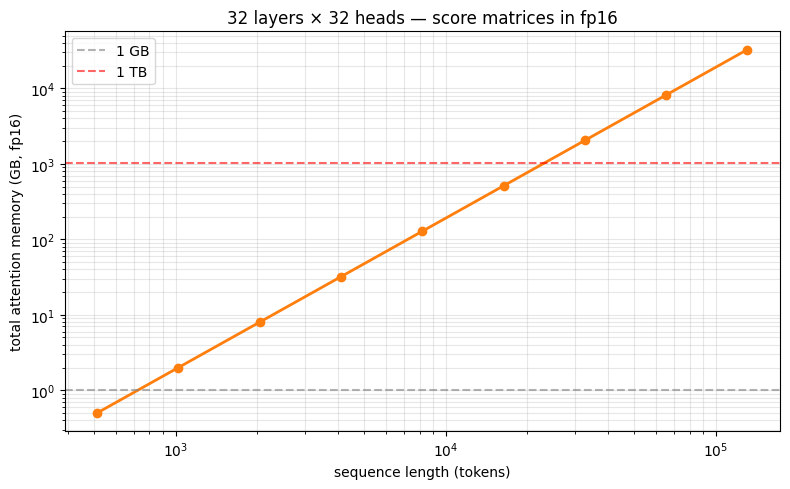

In [3]:
n_layers, n_heads = 32, 32
total_gb = [n_layers * n_heads * (n * n * 2) / (1024 ** 3) for n in lengths]

print(f"{'seq_len':>10} {'total (GB)':>14}")
print('-' * 28)
for n, g in zip(lengths, total_gb):
    print(f'{n:>10} {g:>14.2f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(lengths, total_gb, 'o-', color='C1', linewidth=2)
ax.axhline(1,    color='gray', linestyle='--', alpha=0.6, label='1 GB')
ax.axhline(1024, color='red',  linestyle='--', alpha=0.6, label='1 TB')
ax.set_xlabel('sequence length (tokens)')
ax.set_ylabel('total attention memory (GB, fp16)')
ax.set_title('32 layers × 32 heads — score matrices in fp16')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. KV cache scaling (Llama 3 70B example)

KV cache memory: `2 * n_layers * n_kv_heads * seq_len * d_head * bytes_per_value`.

For Llama 3 70B: 80 layers, 64 KV heads, d_head=128, fp16 → 2 bytes. (Production Llama 3 actually uses GQA with 8 KV heads — this demo shows the *naive* MHA-equivalent cost, which is exactly what Part 5's GQA fixes.)

   seq_len    KV cache (GB)
------------------------------
      1024             2.50
      4096            10.00
      8192            20.00
     16384            40.00
     32768            80.00
     65536           160.00
    131072           320.00


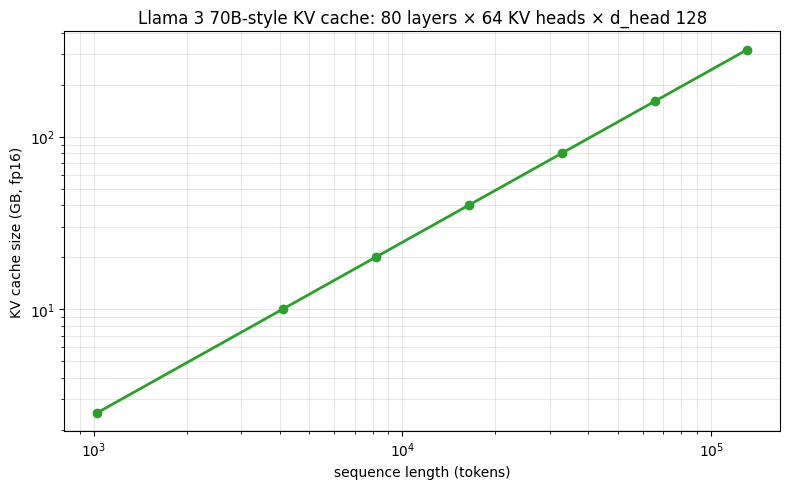

In [4]:
n_layers_l3 = 80
n_kv_heads  = 64
d_head      = 128
bytes_per_value = 2

seq_lens = [1024, 4096, 8192, 16384, 32768, 65536, 131072]
kv_cache_gb = [
    2 * n_layers_l3 * n_kv_heads * sl * d_head * bytes_per_value / (1024 ** 3)
    for sl in seq_lens
]

print(f"{'seq_len':>10} {'KV cache (GB)':>16}")
print('-' * 30)
for sl, g in zip(seq_lens, kv_cache_gb):
    print(f'{sl:>10} {g:>16.2f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(seq_lens, kv_cache_gb, 'o-', color='C2', linewidth=2)
ax.set_xlabel('sequence length (tokens)')
ax.set_ylabel('KV cache size (GB, fp16)')
ax.set_title('Llama 3 70B-style KV cache: 80 layers × 64 KV heads × d_head 128')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Takeaways

1. **Attention scores are O(n²) in memory.** At 128K tokens, the score matrix alone is 32 GB per layer per head.
2. **KV cache is O(n) but with a huge constant.** Larger heads × more layers × longer context → hundreds of GB during inference.
3. **These two problems motivate everything that follows in this series:**
   - **Part 5** (architectural changes — MQA/GQA/MLA): shrink the KV cache.
   - **Part 6** (sparsity): cut the score matrix from O(n²) toward O(n).
   - **Part 7** (Flash Attention): keep the math, change how it runs on hardware to avoid materializing the full score matrix in memory.